In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [12]:
df = pd.read_csv("ecommerce_customers_unit1.csv")
df.head()
print("Shape: ",df.shape)
print('\nData Type: ',df.dtypes)

Shape:  (605, 14)

customer_id             int64
age                   float64
gender                 object
country                object
signup_date            object
last_purchase_date     object
num_orders              int64
total_spent           float64
avg_order_value       float64
recency_days            int64
is_premium_member       int64
device_type            object
preferred_category     object
churned                 int64
dtype: object


numeric columns:  ['customer_id', 'age', 'num_orders', 'total_spent', 'avg_order_value', 'recency_days', 'is_premium_member', 'churned']


<Axes: >

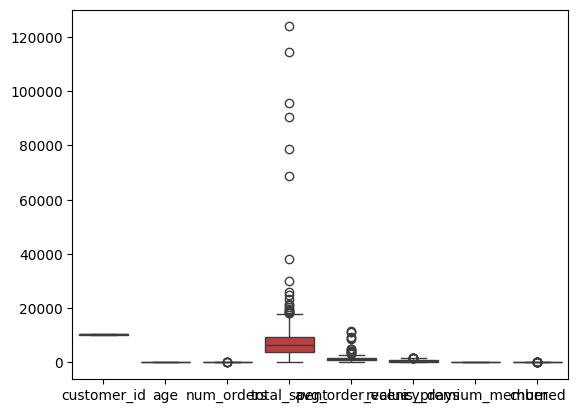

In [28]:
num_cols = df.select_dtypes(include='number').columns
num_cols
print('numeric columns: ',num_cols.tolist())
sns.boxplot(df[num_cols])

   customer_id       age  num_orders  total_spent  avg_order_value  \
0     0.000000  0.745098    0.769231     0.107136         0.116107   
1     0.001669  1.000000    0.769231          NaN         0.027021   
2     0.003339  0.549020    0.384615     0.027539         0.059690   
3     0.005008  0.274510    0.384615     0.036338         0.078762   
4     0.006678  0.823529    0.538462     0.031012         0.048012   

   recency_days  is_premium_member  churned  
0      0.309382                0.0      0.0  
1      0.035629                0.0      0.0  
2      0.939430                0.0      0.0  
3      0.438836                0.0      0.0  
4      0.824822                0.0      0.0  


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'customer_id'),
  Text(1, 0, 'age'),
  Text(2, 0, 'num_orders'),
  Text(3, 0, 'total_spent'),
  Text(4, 0, 'avg_order_value'),
  Text(5, 0, 'recency_days'),
  Text(6, 0, 'is_premium_member'),
  Text(7, 0, 'churned')])

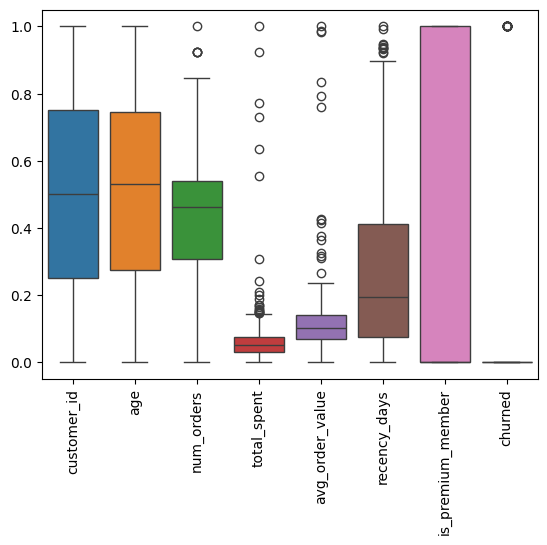

In [35]:
normalizer = MinMaxScaler()

df_normalized = df.copy()
norm_num_cols = df_normalized.select_dtypes(include='number').columns
df_normalized[norm_num_cols] = normalizer.fit_transform(df[norm_num_cols])
print(df_normalized[norm_num_cols].head())
sns.boxplot(df_normalized[norm_num_cols])

plt.xticks(rotation=90)

   customer_id       age  gender country signup_date last_purchase_date  \
0    -1.731715  0.790133    Male   India  2022-01-27         2024-04-27   
1    -1.725952  1.658781   Other      UK  2025-01-12         2025-08-01   
2    -1.720188  0.121942  Female     USA  2021-04-25         2021-06-01   
3    -1.714424 -0.813525    Male   India  2021-02-23         2023-09-22   
4    -1.708660  1.057409  Female   India  2021-06-07         2021-12-11   

   num_orders  total_spent  avg_order_value  recency_days  is_premium_member  \
0    1.739429     0.504370         0.042695      0.162699          -0.645648   
1    1.739429          NaN        -0.864250     -0.974240          -0.645648   
2   -0.405607    -0.449556        -0.531660      2.779384          -0.645648   
3   -0.405607    -0.344100        -0.337495      0.700340          -0.645648   
4    0.452408    -0.407935        -0.650547      2.303399          -0.645648   

  device_type preferred_category   churned  
0         NaN          

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'customer_id'),
  Text(1, 0, 'age'),
  Text(2, 0, 'num_orders'),
  Text(3, 0, 'total_spent'),
  Text(4, 0, 'avg_order_value'),
  Text(5, 0, 'recency_days'),
  Text(6, 0, 'is_premium_member'),
  Text(7, 0, 'churned')])

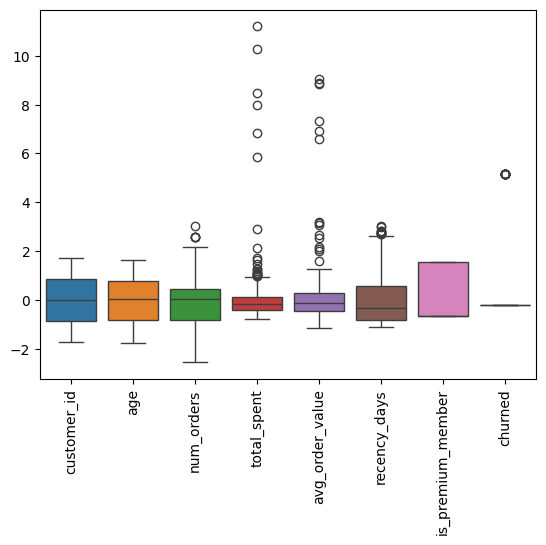

In [36]:
standard = StandardScaler()

df_standard = df.copy()
df_standard[num_cols] = standard.fit_transform(df_standard[num_cols])
print(df_standard.head())
sns.boxplot(df_standard[num_cols])
plt.xticks(rotation=90)

In [44]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

data = {'Color' : ['R','r','Blue','Green','Blue','Red']}
df = pd.DataFrame(data)
print('Original data: \n')
print(df)
lb = LabelEncoder()
df['Color_encoded'] = lb.fit_transform(df['Color'])
print('\nAfter Label Encoding: \n')
print(df)

Original data: 

   Color
0      R
1      r
2   Blue
3  Green
4   Blue
5    Red

After Label Encoding: 

   Color  Color_encoded
0      R              2
1      r              4
2   Blue              0
3  Green              1
4   Blue              0
5    Red              3


After Label Encoding: 
     country  country_encoded
0      India                3
1         UK                4
2        USA                5
3      India                3
4      India                3
..       ...              ...
600    India                3
601      USA                5
602    India                3
603       UK                4
604  Germany                2

[605 rows x 2 columns]


<BarContainer object of 605 artists>

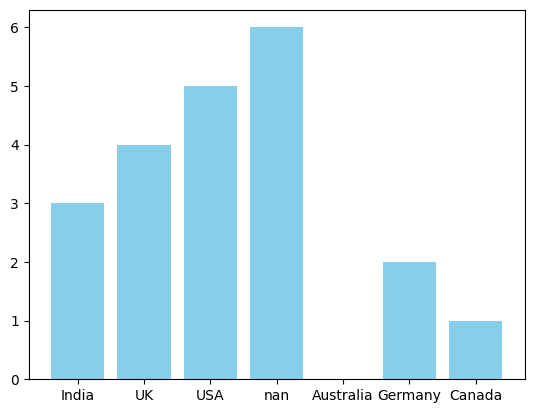

In [52]:
cat_cols = df_normalized.select_dtypes(exclude='number').columns

le = LabelEncoder()
df_normalized['country_encoded'] = le.fit_transform(df_normalized['country'])
print("After Label Encoding: ")
df_normalized['country'] = df_normalized['country'].astype(str)
print(df_normalized[['country','country_encoded']])
plt.bar(df_normalized['country'],df_normalized['country_encoded'],color='skyblue')

In [60]:
# One Hot Encoding
data = {'Color' : ['R','r','Blue','Green','Blue','Red']}
df = pd.DataFrame(data)

df_oh = pd.get_dummies(df,columns=['Color'])
print('One Hot Encoding')
print(df_oh)

One Hot Encoding
   Color_Blue  Color_Green  Color_R  Color_Red  Color_r
0       False        False     True      False    False
1       False        False    False      False     True
2        True        False    False      False    False
3       False         True    False      False    False
4        True        False    False      False    False
5       False        False    False       True    False


In [57]:
from sklearn.preprocessing import OneHotEncoder

df_onehot = pd.get_dummies(df_standard,columns = ['country'])
print('One Hot Encoding')
print(df_onehot)

One Hot Encoding
     customer_id       age  gender signup_date last_purchase_date  num_orders  \
0      -1.731715  0.790133    Male  2022-01-27         2024-04-27    1.739429   
1      -1.725952  1.658781   Other  2025-01-12         2025-08-01    1.739429   
2      -1.720188  0.121942  Female  2021-04-25         2021-06-01   -0.405607   
3      -1.714424 -0.813525    Male  2021-02-23         2023-09-22   -0.405607   
4      -1.708660  1.057409  Female  2021-06-07         2021-12-11    0.452408   
..           ...       ...     ...         ...                ...         ...   
600     0.326010 -1.281259  Female  2023-09-04         2025-06-18    0.452408   
601    -1.063099  0.389218    Male  2024-05-11         2024-11-08   -0.834614   
602     1.715119  0.121942    Male  2020-12-01         2024-06-25    0.023400   
603     0.810181 -0.813525  Female  2023-12-20         2024-09-20   -1.263621   
604     1.461506 -0.011696  Female  2024-06-16         2024-12-09    0.023400   

     total